In [1]:
import json, os, sys, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import wilcoxon
warnings.filterwarnings('ignore')

sys.path.insert(0, '.')

# ── Constants ──────────────────────────────────────────────────────────────────
INSTANCES  = ['eil51', 'kroA100', 'ch150']
ALGORITHMS = ['RL-AGA', 'NSGA2', 'MOEAD', 'GA-Static', 'GA-Random']

ALG_LABELS = {
    'RL-AGA'   : 'RL-AGA (ours)',
    'NSGA2'    : 'NSGA-II',
    'MOEAD'    : 'MOEA/D',
    'GA-Static': 'GA-Static',
    'GA-Random': 'GA-Random'
}
ALG_COLORS = {
    'RL-AGA'   : '#1f77b4',
    'NSGA2'    : '#ff7f0e',
    'MOEAD'    : '#2ca02c',
    'GA-Static': '#d62728',
    'GA-Random': '#9467bd'
}

os.makedirs('paper_tables', exist_ok=True)
print('Phase 5 ready.')

Phase 5 ready.


In [2]:
def load_results(inst, alg):
    path = f'results/{inst}_{alg}.json'
    return json.load(open(path, encoding='utf-8'))

# Load everything into a nested dict
results = {}
for inst in INSTANCES:
    results[inst] = {}
    for alg in ALGORITHMS:
        data = load_results(inst, alg)
        results[inst][alg] = data

# Quick summary
print(f'{"Instance":<12} {"Algorithm":<14} {"Runs":>5} {"Avg archive":>12}')
print('-' * 48)
for inst in INSTANCES:
    for alg in ALGORITHMS:
        data = results[inst][alg]
        avg  = np.mean([len(r['archive_objs']) for r in data])
        print(f'{inst:<12} {alg:<14} {len(data):>5} {avg:>12.1f}')
    print()

Instance     Algorithm       Runs  Avg archive
------------------------------------------------
eil51        RL-AGA            20         46.0
eil51        NSGA2             20        185.3
eil51        MOEAD             20         42.0
eil51        GA-Static         20         34.8
eil51        GA-Random         20         88.2

kroA100      RL-AGA            20          9.4
kroA100      NSGA2             20         81.0
kroA100      MOEAD             20          8.1
kroA100      GA-Static         20          7.5
kroA100      GA-Random         20         33.4

ch150        RL-AGA            20         14.8
ch150        NSGA2             20         90.9
ch150        MOEAD             20         15.1
ch150        GA-Static         20         11.8
ch150        GA-Random         20         75.7



In [3]:
# Compute global min/max per objective per instance
# Used to normalise objectives consistently for HV and IGD
global_bounds = {}

for inst in INSTANCES:
    all_pts = []
    for alg in ALGORITHMS:
        for run in results[inst][alg]:
            if run['archive_objs']:
                all_pts.extend(run['archive_objs'])
    all_pts = np.array(all_pts)   # shape (total_solutions, 3)
    global_bounds[inst] = {
        'min': all_pts.min(axis=0),
        'max': all_pts.max(axis=0)
    }
    span = global_bounds[inst]['max'] - global_bounds[inst]['min']
    print(f'{inst}:  min=[{global_bounds[inst]["min"][0]:.1f}, '
          f'{global_bounds[inst]["min"][1]:.1f}, '
          f'{global_bounds[inst]["min"][2]:.1f}]')
    print(f'        max=[{global_bounds[inst]["max"][0]:.1f}, '
          f'{global_bounds[inst]["max"][1]:.1f}, '
          f'{global_bounds[inst]["max"][2]:.1f}]')
    print(f'        span=[{span[0]:.1f}, {span[1]:.1f}, {span[2]:.1f}]\n')


def normalise_pts(pts, bounds):
    """Normalise objective vectors to [0,1] using global bounds."""
    pts    = np.array(pts)
    denom  = bounds['max'] - bounds['min']
    denom  = np.where(denom < 1e-10, 1.0, denom)
    return (pts - bounds['min']) / denom

eil51:  min=[436.2, 426.1, 2269.9]
        max=[709.1, 940.9, 3331.9]
        span=[272.8, 514.8, 1062.0]

kroA100:  min=[21346.9, 19744.3, 34246.9]
        max=[27386.6, 33796.4, 44388.9]
        span=[6039.8, 14052.1, 10142.0]

ch150:  min=[6649.0, 6966.0, 16530.7]
        max=[8722.2, 10586.2, 19832.0]
        span=[2073.3, 3620.2, 3301.3]



In [4]:
def is_dominated(pt, others):
    """True if pt is dominated by any point in others."""
    return any(np.all(o <= pt) and np.any(o < pt) for o in others)

def get_pareto_front(points):
    """Filter to non-dominated subset."""
    pts  = np.array(points)
    keep = []
    for i, p in enumerate(pts):
        others = np.delete(pts, i, axis=0)
        if not is_dominated(p, others):
            keep.append(p)
    return np.array(keep) if keep else pts[:1]

# Build reference front per instance:
# union of ALL non-dominated solutions from ALL algorithms, ALL runs
reference_fronts = {}

for inst in INSTANCES:
    all_pts = []
    for alg in ALGORITHMS:
        for run in results[inst][alg]:
            if run['archive_objs']:
                # Normalise before pooling
                norm = normalise_pts(run['archive_objs'], global_bounds[inst])
                all_pts.extend(norm.tolist())

    all_pts = np.array(all_pts)
    ref = get_pareto_front(all_pts)
    reference_fronts[inst] = ref
    print(f'{inst}: reference front = {len(ref)} points '
          f'(from {len(all_pts)} total pooled solutions)')

eil51: reference front = 479 points (from 7926 total pooled solutions)
kroA100: reference front = 97 points (from 2789 total pooled solutions)
ch150: reference front = 218 points (from 4166 total pooled solutions)


In [5]:
from pymoo.indicators.hv  import HV
from pymoo.indicators.igd import IGD

# HV reference point: 1.1 in all normalised dimensions
HV_REF_POINT = np.array([1.1, 1.1, 1.1])

metrics = {}   # metrics[inst][alg] = {'hv': [...], 'igd': [...]}

for inst in INSTANCES:
    metrics[inst] = {}
    ref_front = reference_fronts[inst]
    hv_ind    = HV(ref_point=HV_REF_POINT)
    igd_ind   = IGD(ref_front)

    for alg in ALGORITHMS:
        hvs, igds = [], []
        for run in results[inst][alg]:
            if run['archive_objs']:
                F_norm = normalise_pts(run['archive_objs'],
                                       global_bounds[inst])
                # Clip to [0, 1.05] to avoid numerical issues
                F_norm = np.clip(F_norm, 0, 1.05)
                hvs.append(float(hv_ind(F_norm)))
                igds.append(float(igd_ind(F_norm)))
            else:
                hvs.append(0.0)
                igds.append(np.inf)

        metrics[inst][alg] = {
            'hv' : np.array(hvs),
            'igd': np.array(igds)
        }

# Print summary
print(f'{"":30} {"HV mean":>10} {"HV std":>8} {"IGD mean":>10} {"IGD std":>8}')
print('-' * 70)
for inst in INSTANCES:
    print(f'--- {inst} ---')
    for alg in ALGORITHMS:
        m   = metrics[inst][alg]
        hv_m, hv_s  = m['hv'].mean(),  m['hv'].std()
        igd_m, igd_s = m['igd'].mean(), m['igd'].std()
        marker = ' ◄' if alg == 'RL-AGA' else ''
        print(f'  {alg:<26} {hv_m:>10.4f} {hv_s:>8.4f} '
              f'{igd_m:>10.4f} {igd_s:>8.4f}{marker}')
    print()

                                  HV mean   HV std   IGD mean  IGD std
----------------------------------------------------------------------
--- eil51 ---
  RL-AGA                         0.7292   0.0718     0.1250   0.0272 ◄
  NSGA2                          0.5525   0.0553     0.2715   0.0385
  MOEAD                          0.6626   0.0340     0.1479   0.0145
  GA-Static                      0.6329   0.0415     0.1696   0.0246
  GA-Random                      0.8169   0.0543     0.0893   0.0209

--- kroA100 ---
  RL-AGA                         0.8986   0.1678     0.1514   0.0878 ◄
  NSGA2                          0.1970   0.0827     0.8202   0.1499
  MOEAD                          0.7381   0.1620     0.2383   0.1169
  GA-Static                      0.7490   0.1696     0.2345   0.1114
  GA-Random                      1.0754   0.1221     0.0837   0.0592

--- ch150 ---
  RL-AGA                         0.7093   0.0651     0.1907   0.0265 ◄
  NSGA2                          0.1661   0.091

In [6]:
sig_results = {}   # sig_results[inst][alg] = {p_hv, p_igd, sig_hv, sig_igd}

ALPHA = 0.05

for inst in INSTANCES:
    sig_results[inst] = {}
    rl_hv  = metrics[inst]['RL-AGA']['hv']
    rl_igd = metrics[inst]['RL-AGA']['igd']

    print(f'=== {inst} ===')
    print(f'  {"Baseline":<14} {"p-val HV":>10} {"p-val IGD":>10} '
          f'{"HV sig":>8} {"IGD sig":>8}')
    print('  ' + '-' * 54)

    for alg in ALGORITHMS:
        if alg == 'RL-AGA':
            continue
        b_hv  = metrics[inst][alg]['hv']
        b_igd = metrics[inst][alg]['igd']

        # One-sided: is RL-AGA significantly better?
        try:
            _, p_hv  = wilcoxon(rl_hv,  b_hv,  alternative='greater')
        except Exception:
            p_hv = 1.0
        try:
            _, p_igd = wilcoxon(rl_igd, b_igd, alternative='less')
        except Exception:
            p_igd = 1.0

        sig_results[inst][alg] = {
            'p_hv' : p_hv,  'p_igd' : p_igd,
            'sig_hv' : p_hv  < ALPHA,
            'sig_igd': p_igd < ALPHA
        }

        hv_mark  = '✓' if p_hv  < ALPHA else '✗'
        igd_mark = '✓' if p_igd < ALPHA else '✗'
        print(f'  {alg:<14} {p_hv:>10.4f} {p_igd:>10.4f} '
              f'{hv_mark:>8} {igd_mark:>8}')
    print()

=== eil51 ===
  Baseline         p-val HV  p-val IGD   HV sig  IGD sig
  ------------------------------------------------------
  NSGA2              0.0000     0.0000        ✓        ✓
  MOEAD              0.0016     0.0047        ✓        ✓
  GA-Static          0.0001     0.0002        ✓        ✓
  GA-Random          0.9995     0.9998        ✗        ✗

=== kroA100 ===
  Baseline         p-val HV  p-val IGD   HV sig  IGD sig
  ------------------------------------------------------
  NSGA2              0.0000     0.0000        ✓        ✓
  MOEAD              0.0032     0.0036        ✓        ✓
  GA-Static          0.0032     0.0042        ✓        ✓
  GA-Random          0.9992     0.9953        ✗        ✗

=== ch150 ===
  Baseline         p-val HV  p-val IGD   HV sig  IGD sig
  ------------------------------------------------------
  NSGA2              0.0000     0.0000        ✓        ✓
  MOEAD              0.4927     0.9800        ✗        ✗
  GA-Static          0.0096     0.1942    

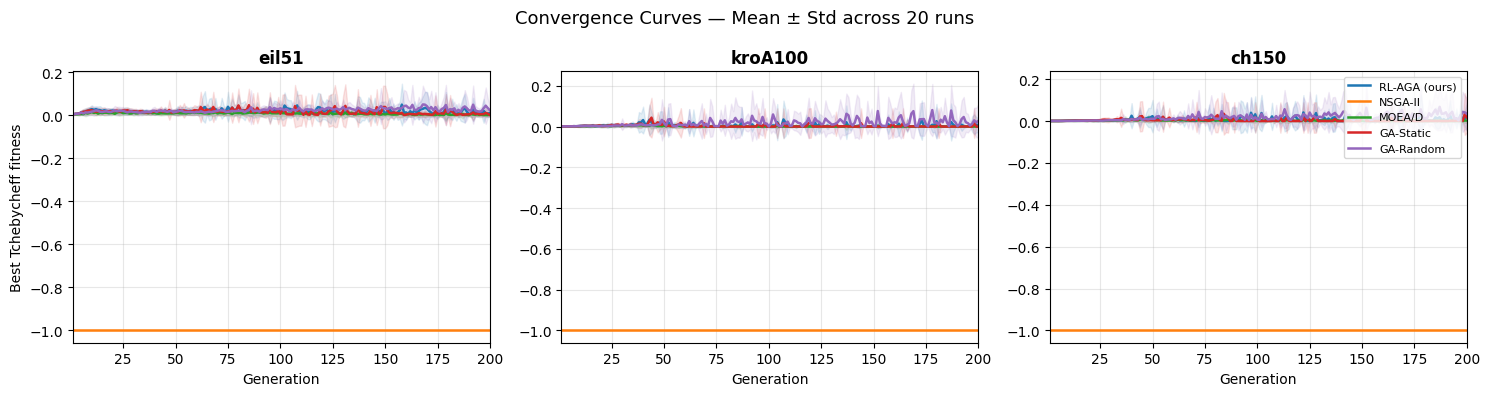

Figure 1 saved: paper_tables/fig1_convergence.pdf


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax_idx, inst in enumerate(INSTANCES):
    ax = axes[ax_idx]
    for alg in ALGORITHMS:
        # Collect per-generation f_best from all runs
        run_logs = [r['log'] for r in results[inst][alg] if r['log']]
        if not run_logs:
            continue
        max_g  = max(len(log) for log in run_logs)
        matrix = np.full((len(run_logs), max_g), np.nan)
        for i, log in enumerate(run_logs):
            vals = [entry['f_best'] for entry in log]
            matrix[i, :len(vals)] = vals

        mean_curve = np.nanmean(matrix, axis=0)
        std_curve  = np.nanstd(matrix,  axis=0)
        gens       = np.arange(1, len(mean_curve) + 1)

        ax.plot(gens, mean_curve,
                color=ALG_COLORS[alg],
                label=ALG_LABELS[alg], lw=1.8)
        ax.fill_between(gens,
                         mean_curve - std_curve,
                         mean_curve + std_curve,
                         color=ALG_COLORS[alg], alpha=0.12)

    ax.set_title(inst, fontsize=12, fontweight='bold')
    ax.set_xlabel('Generation', fontsize=10)
    ax.set_ylabel('Best Tchebycheff fitness' if ax_idx == 0 else '', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(1, 200)
    if ax_idx == 2:
        ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Convergence Curves — Mean ± Std across 20 runs', fontsize=13)
plt.tight_layout()
plt.savefig('paper_tables/fig1_convergence.pdf', bbox_inches='tight', dpi=300)
plt.show()
print('Figure 1 saved: paper_tables/fig1_convergence.pdf')

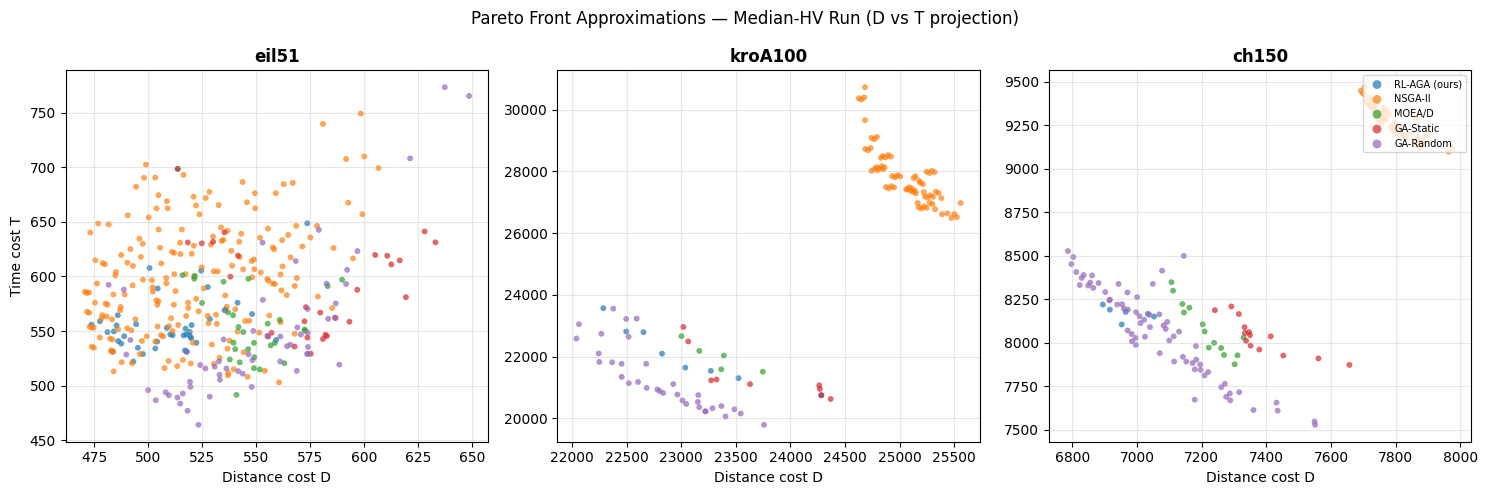

Figure 2 saved: paper_tables/fig2_pareto_fronts.pdf


In [8]:
# For each instance, show the median-HV run's Pareto front for each algorithm
# Use D vs T projection (most informative for logistics)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax_idx, inst in enumerate(INSTANCES):
    ax = axes[ax_idx]
    bounds = global_bounds[inst]

    for alg in ALGORITHMS:
        # Pick the run closest to median HV
        hvs     = metrics[inst][alg]['hv']
        med_idx = np.argsort(hvs)[len(hvs) // 2]
        run     = results[inst][alg][med_idx]

        if not run['archive_objs']:
            continue
        F = np.array(run['archive_objs'])

        # Plot D vs T (unnormalised for interpretability)
        ax.scatter(F[:, 0], F[:, 1],
                   color=ALG_COLORS[alg],
                   label=ALG_LABELS[alg],
                   s=18, alpha=0.7, edgecolors='none')

    ax.set_title(f'{inst}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Distance cost D', fontsize=10)
    ax.set_ylabel('Time cost T' if ax_idx == 0 else '', fontsize=10)
    ax.grid(True, alpha=0.3)
    if ax_idx == 2:
        ax.legend(fontsize=7, loc='upper right', markerscale=1.5)

plt.suptitle('Pareto Front Approximations — Median-HV Run (D vs T projection)',
             fontsize=12)
plt.tight_layout()
plt.savefig('paper_tables/fig2_pareto_fronts.pdf', bbox_inches='tight', dpi=300)
plt.show()
print('Figure 2 saved: paper_tables/fig2_pareto_fronts.pdf')

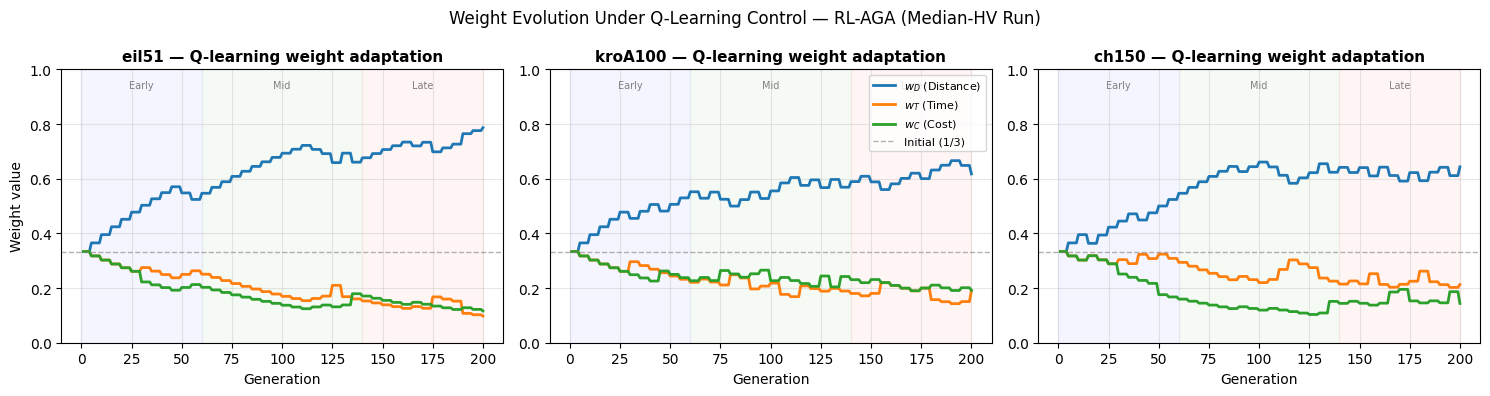

Figure 3 saved: paper_tables/fig3_weight_evolution.pdf


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax_idx, inst in enumerate(INSTANCES):
    ax = axes[ax_idx]

    # Use the median-HV RL-AGA run
    hvs     = metrics[inst]['RL-AGA']['hv']
    med_idx = np.argsort(hvs)[len(hvs) // 2]
    log     = results[inst]['RL-AGA'][med_idx]['log']

    gens  = [entry['g'] for entry in log]
    w_arr = np.array([entry['w'] for entry in log])

    ax.plot(gens, w_arr[:, 0], color='#1f77b4', lw=2, label='$w_D$ (Distance)')
    ax.plot(gens, w_arr[:, 1], color='#ff7f0e', lw=2, label='$w_T$ (Time)')
    ax.plot(gens, w_arr[:, 2], color='#2ca02c', lw=2, label='$w_C$ (Cost)')
    ax.axhline(1/3, color='gray', ls='--', lw=1, alpha=0.6, label='Initial (1/3)')

    # Shade generation phases
    g_max = max(gens)
    ax.axvspan(0,          0.3*g_max, alpha=0.04, color='blue')
    ax.axvspan(0.3*g_max,  0.7*g_max, alpha=0.04, color='green')
    ax.axvspan(0.7*g_max,  g_max,     alpha=0.04, color='red')

    ax.set_title(f'{inst} — Q-learning weight adaptation', fontsize=11, fontweight='bold')
    ax.set_xlabel('Generation', fontsize=10)
    ax.set_ylabel('Weight value' if ax_idx == 0 else '', fontsize=10)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    if ax_idx == 1:
        ax.legend(fontsize=8, loc='upper right')

    # Annotate phase boundaries
    for label, x in [('Early', 0.15*g_max),
                      ('Mid',   0.5*g_max),
                      ('Late',  0.85*g_max)]:
        ax.text(x, 0.96, label, ha='center', va='top',
                fontsize=7, color='gray', transform=ax.get_xaxis_transform())

plt.suptitle('Weight Evolution Under Q-Learning Control — RL-AGA (Median-HV Run)',
             fontsize=12)
plt.tight_layout()
plt.savefig('paper_tables/fig3_weight_evolution.pdf', bbox_inches='tight', dpi=300)
plt.show()
print('Figure 3 saved: paper_tables/fig3_weight_evolution.pdf')

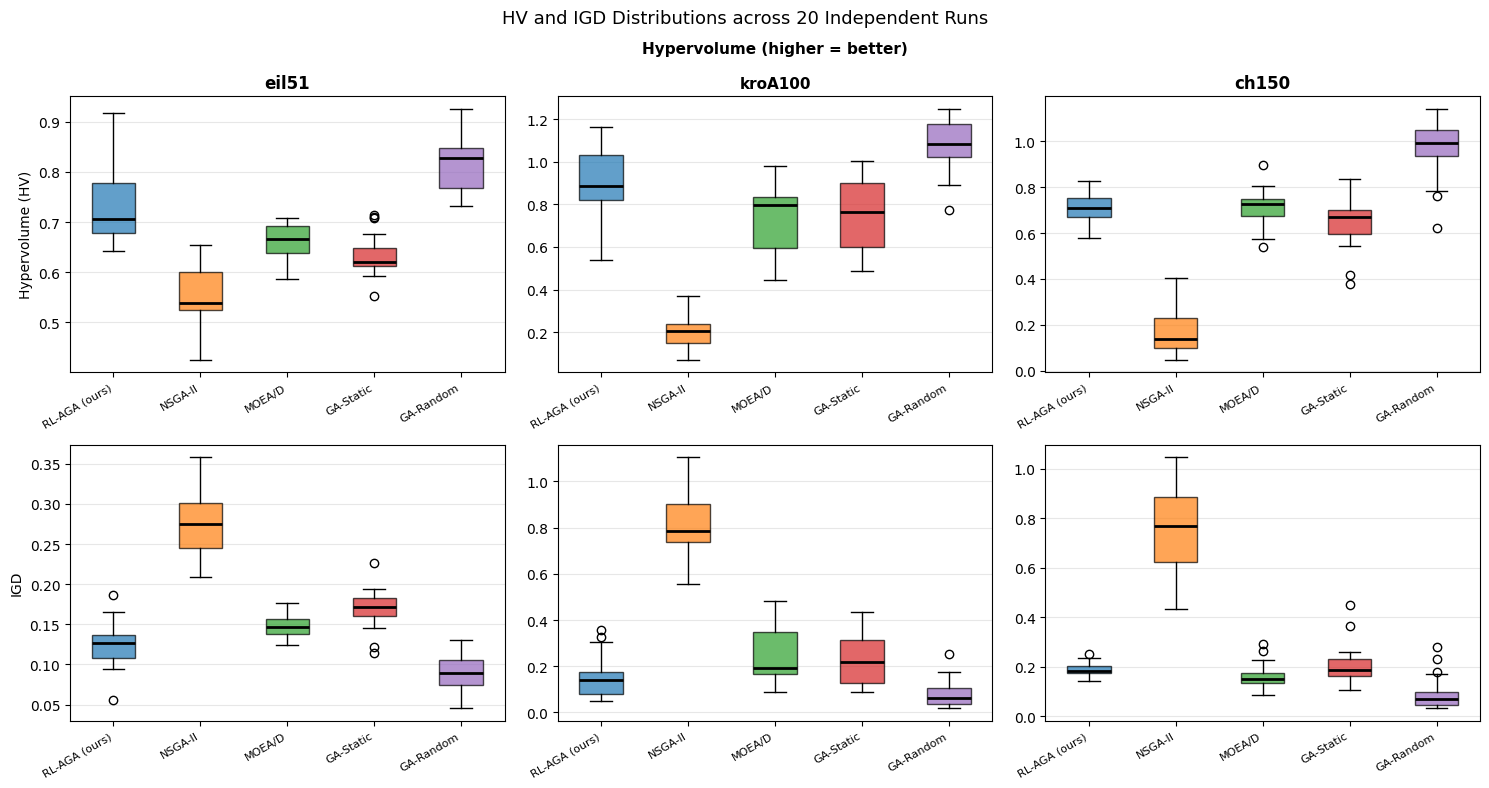

Figure 4 saved: paper_tables/fig4_boxplots.pdf


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for col, inst in enumerate(INSTANCES):
    # HV box plot (top row)
    ax_hv = axes[0, col]
    hv_data   = [metrics[inst][alg]['hv']  for alg in ALGORITHMS]
    bp = ax_hv.boxplot(hv_data, patch_artist=True, notch=False,
                        medianprops=dict(color='black', lw=2))
    for patch, alg in zip(bp['boxes'], ALGORITHMS):
        patch.set_facecolor(ALG_COLORS[alg])
        patch.set_alpha(0.7)
    ax_hv.set_title(f'{inst}', fontsize=12, fontweight='bold')
    ax_hv.set_ylabel('Hypervolume (HV)' if col == 0 else '', fontsize=10)
    ax_hv.set_xticks(range(1, len(ALGORITHMS)+1))
    ax_hv.set_xticklabels([ALG_LABELS[a] for a in ALGORITHMS],
                            rotation=30, ha='right', fontsize=8)
    ax_hv.grid(True, alpha=0.3, axis='y')

    # IGD box plot (bottom row)
    ax_igd = axes[1, col]
    igd_data  = [metrics[inst][alg]['igd'] for alg in ALGORITHMS]
    bp2 = ax_igd.boxplot(igd_data, patch_artist=True, notch=False,
                          medianprops=dict(color='black', lw=2))
    for patch, alg in zip(bp2['boxes'], ALGORITHMS):
        patch.set_facecolor(ALG_COLORS[alg])
        patch.set_alpha(0.7)
    ax_igd.set_ylabel('IGD' if col == 0 else '', fontsize=10)
    ax_igd.set_xticks(range(1, len(ALGORITHMS)+1))
    ax_igd.set_xticklabels([ALG_LABELS[a] for a in ALGORITHMS],
                             rotation=30, ha='right', fontsize=8)
    ax_igd.grid(True, alpha=0.3, axis='y')

axes[0, 1].set_title('Hypervolume (higher = better)\n\nkroA100',
                      fontsize=11, fontweight='bold')
plt.suptitle('HV and IGD Distributions across 20 Independent Runs', fontsize=13)
plt.tight_layout()
plt.savefig('paper_tables/fig4_boxplots.pdf', bbox_inches='tight', dpi=300)
plt.show()
print('Figure 4 saved: paper_tables/fig4_boxplots.pdf')

In [11]:
def format_cell(mean, std, is_best, is_rl_aga):
    """Format a table cell with mean±std, bold if best."""
    cell = f'{mean:.4f}$\\pm${std:.4f}'
    if is_best:
        cell = f'\\textbf{{{cell}}}'
    return cell

def make_results_table(inst):
    """Generate complete LaTeX table for one instance."""
    lines = []
    lines.append(f'% ── {inst} ────────────────────────────────────────────')
    lines.append(f'\\begin{{table}}[t]')
    lines.append(f'  \\caption{{Performance Comparison on {inst}}}')
    lines.append(f'  \\label{{tab:results_{inst}}}')
    lines.append(f'  \\centering')
    lines.append(f'  \\begin{{tabular}}{{lcccc}}')
    lines.append(f'    \\hline')
    lines.append(f'    \\textbf{{Algorithm}} & \\textbf{{HV (mean$\\pm$std)}} & '
                 f'\\textbf{{IGD (mean$\\pm$std)}} & \\textbf{{$|\\mathcal{{A}}^*|$}} & '
                 f'\\textbf{{Time (s)}} \\\\')
    lines.append(f'    \\hline')

    # Find best HV and IGD
    all_hv_means  = {a: metrics[inst][a]['hv'].mean()  for a in ALGORITHMS}
    all_igd_means = {a: metrics[inst][a]['igd'].mean() for a in ALGORITHMS}
    best_hv_alg   = max(all_hv_means,  key=all_hv_means.get)
    best_igd_alg  = min(all_igd_means, key=all_igd_means.get)

    for alg in ALGORITHMS:
        m       = metrics[inst][alg]
        hv_m    = m['hv'].mean();  hv_s  = m['hv'].std()
        igd_m   = m['igd'].mean(); igd_s = m['igd'].std()
        arc_m   = np.mean([len(r['archive_objs'])
                           for r in results[inst][alg]])
        time_m  = np.mean([r['runtime_s']
                           for r in results[inst][alg]])

        # Significance daggers
        if alg != 'RL-AGA' and alg in sig_results.get(inst, {}):
            dag_hv  = '$^\\dagger$' if sig_results[inst][alg]['sig_hv']  else ''
            dag_igd = '$^\\dagger$' if sig_results[inst][alg]['sig_igd'] else ''
        else:
            dag_hv = dag_igd = ''

        hv_cell  = format_cell(hv_m,  hv_s,  alg == best_hv_alg,  alg == 'RL-AGA')
        igd_cell = format_cell(igd_m, igd_s, alg == best_igd_alg, alg == 'RL-AGA')

        label = f'\\textbf{{{ALG_LABELS[alg]}}}' if alg == 'RL-AGA' \
                else ALG_LABELS[alg]

        lines.append(f'    {label} & {hv_cell}{dag_hv} & '
                     f'{igd_cell}{dag_igd} & {arc_m:.0f} & {time_m:.1f} \\\\')

    lines.append(f'    \\hline')
    lines.append(f'  \\end{{tabular}}')
    lines.append(f'  \\\\[2pt]')
    lines.append(f'  \\footnotesize{{$^\\dagger$~RL-AGA is statistically '
                 f'significantly better (Wilcoxon signed-rank, $p<0.05$).}}')
    lines.append(f'\\end{{table}}')
    lines.append('')
    return '\n'.join(lines)


# Generate all three tables
all_tables = '% Auto-generated by phase5_analysis.ipynb\n'
all_tables += '% Add \\usepackage{booktabs} to your preamble\n\n'
for inst in INSTANCES:
    all_tables += make_results_table(inst) + '\n'

with open('paper_tables/results_tables.tex', 'w', encoding='utf-8') as f:
    f.write(all_tables)

print('LaTeX tables saved: paper_tables/results_tables.tex')
print()
print('Preview of eil51 table:')
print(make_results_table('eil51'))

LaTeX tables saved: paper_tables/results_tables.tex

Preview of eil51 table:
% ── eil51 ────────────────────────────────────────────
\begin{table}[t]
  \caption{Performance Comparison on eil51}
  \label{tab:results_eil51}
  \centering
  \begin{tabular}{lcccc}
    \hline
    \textbf{Algorithm} & \textbf{HV (mean$\pm$std)} & \textbf{IGD (mean$\pm$std)} & \textbf{$|\mathcal{A}^*|$} & \textbf{Time (s)} \\
    \hline
    \textbf{RL-AGA (ours)} & 0.7292$\pm$0.0718 & 0.1250$\pm$0.0272 & 46 & 41.4 \\
    NSGA-II & 0.5525$\pm$0.0553$^\dagger$ & 0.2715$\pm$0.0385$^\dagger$ & 185 & 131.4 \\
    MOEA/D & 0.6626$\pm$0.0340$^\dagger$ & 0.1479$\pm$0.0145$^\dagger$ & 42 & 29.9 \\
    GA-Static & 0.6329$\pm$0.0415$^\dagger$ & 0.1696$\pm$0.0246$^\dagger$ & 35 & 29.4 \\
    GA-Random & \textbf{0.8169$\pm$0.0543} & \textbf{0.0893$\pm$0.0209} & 88 & 45.1 \\
    \hline
  \end{tabular}
  \\[2pt]
  \footnotesize{$^\dagger$~RL-AGA is statistically significantly better (Wilcoxon signed-rank, $p<0.05$).}
\end{ta

In [12]:
print('='*65)
print('EXPERIMENT SUMMARY')
print('='*65)

for inst in INSTANCES:
    print(f'\n{inst}:')
    rl_hv  = metrics[inst]['RL-AGA']['hv'].mean()
    rl_igd = metrics[inst]['RL-AGA']['igd'].mean()

    wins_hv  = sum(1 for a in ALGORITHMS if a != 'RL-AGA'
                   and metrics[inst][a]['hv'].mean()  < rl_hv)
    wins_igd = sum(1 for a in ALGORITHMS if a != 'RL-AGA'
                   and metrics[inst][a]['igd'].mean() > rl_igd)

    print(f'  RL-AGA HV  = {rl_hv:.4f}  '
          f'(beats {wins_hv}/4 baselines on HV)')
    print(f'  RL-AGA IGD = {rl_igd:.4f}  '
          f'(beats {wins_igd}/4 baselines on IGD)')

    sig_count_hv  = sum(1 for a in sig_results.get(inst,{}).values()
                        if a['sig_hv'])
    sig_count_igd = sum(1 for a in sig_results.get(inst,{}).values()
                        if a['sig_igd'])
    print(f'  Statistical significance: '
          f'{sig_count_hv}/4 on HV, {sig_count_igd}/4 on IGD (p<0.05)')

print('\n' + '='*65)
print('FILES GENERATED:')
for f in sorted(os.listdir('paper_tables')):
    if f.endswith('.pdf') or f.endswith('.tex'):
        size = os.path.getsize(f'paper_tables/{f}')
        print(f'  paper_tables/{f}  ({size//1024}KB)')

EXPERIMENT SUMMARY

eil51:
  RL-AGA HV  = 0.7292  (beats 3/4 baselines on HV)
  RL-AGA IGD = 0.1250  (beats 3/4 baselines on IGD)
  Statistical significance: 3/4 on HV, 3/4 on IGD (p<0.05)

kroA100:
  RL-AGA HV  = 0.8986  (beats 3/4 baselines on HV)
  RL-AGA IGD = 0.1514  (beats 3/4 baselines on IGD)
  Statistical significance: 3/4 on HV, 3/4 on IGD (p<0.05)

ch150:
  RL-AGA HV  = 0.7093  (beats 2/4 baselines on HV)
  RL-AGA IGD = 0.1907  (beats 2/4 baselines on IGD)
  Statistical significance: 2/4 on HV, 1/4 on IGD (p<0.05)

FILES GENERATED:
  paper_tables/city_maps.pdf  (20KB)
  paper_tables/fig1_convergence.pdf  (77KB)
  paper_tables/fig2_pareto_fronts.pdf  (39KB)
  paper_tables/fig3_weight_evolution.pdf  (34KB)
  paper_tables/fig4_boxplots.pdf  (33KB)
  paper_tables/phase2_convergence_test.pdf  (13KB)
  paper_tables/phase3_weight_evolution.pdf  (20KB)
  paper_tables/results_tables.tex  (3KB)


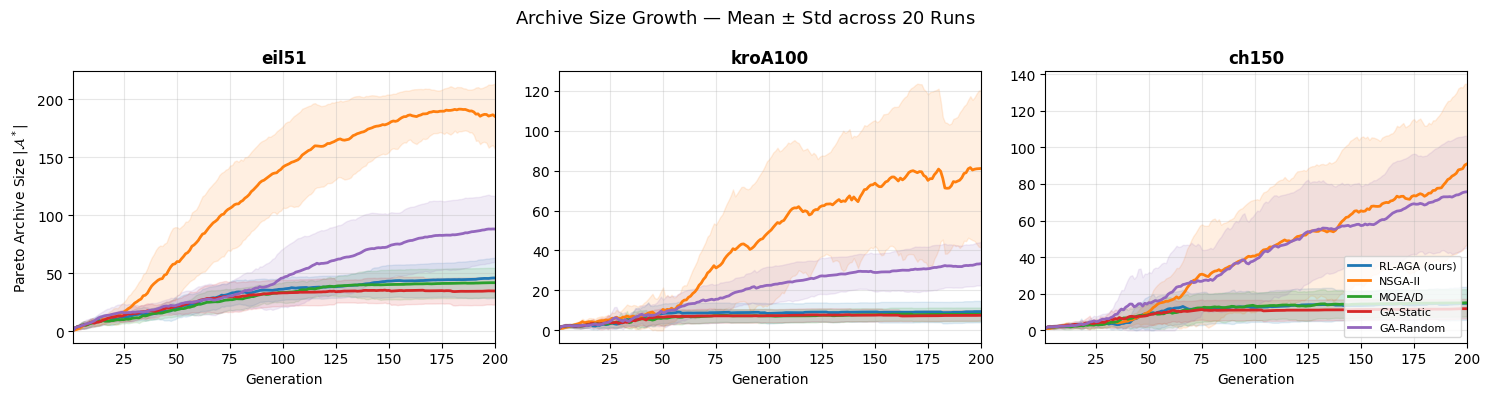

Fixed Figure 1 saved.


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax_idx, inst in enumerate(INSTANCES):
    ax = axes[ax_idx]
    for alg in ALGORITHMS:
        run_logs = [r['log'] for r in results[inst][alg] if r['log']]
        if not run_logs:
            continue
        max_g  = max(len(log) for log in run_logs)
        matrix = np.full((len(run_logs), max_g), np.nan)
        for i, log in enumerate(run_logs):
            vals = [entry['archive_size'] for entry in log]
            matrix[i, :len(vals)] = vals

        mean_curve = np.nanmean(matrix, axis=0)
        std_curve  = np.nanstd(matrix,  axis=0)
        gens       = np.arange(1, len(mean_curve) + 1)

        ax.plot(gens, mean_curve,
                color=ALG_COLORS[alg],
                label=ALG_LABELS[alg], lw=2)
        ax.fill_between(gens,
                         np.maximum(0, mean_curve - std_curve),
                         mean_curve + std_curve,
                         color=ALG_COLORS[alg], alpha=0.12)

    ax.set_title(inst, fontsize=12, fontweight='bold')
    ax.set_xlabel('Generation', fontsize=10)
    if ax_idx == 0:
        ax.set_ylabel('Pareto Archive Size $|\\mathcal{A}^*|$', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(1, 200)
    if ax_idx == 2:
        ax.legend(fontsize=8, loc='lower right')

plt.suptitle('Archive Size Growth — Mean $\\pm$ Std across 20 Runs', fontsize=13)
plt.tight_layout()
plt.savefig('paper_tables/fig1_archive_growth.pdf', bbox_inches='tight', dpi=300)
plt.show()
print('Fixed Figure 1 saved.')

In [14]:
print('='*65)
print('FINAL RESULTS SUMMARY')
print('='*65)

for inst in INSTANCES:
    print(f'\n{inst}:')
    for alg in ALGORITHMS:
        m = metrics[inst][alg]
        print(f'  {alg:<14}  HV={m["hv"].mean():.4f}±{m["hv"].std():.4f}  '
              f'IGD={m["igd"].mean():.4f}±{m["igd"].std():.4f}')

print('\n\nWILCOXON RESULTS (RL-AGA vs each baseline):')
print(f'{"Instance":<10} {"Baseline":<14} {"p-HV":>8} {"p-IGD":>8} '
      f'{"HV sig":>8} {"IGD sig":>8}')
print('-'*55)
for inst in INSTANCES:
    for alg in sig_results.get(inst, {}):
        s = sig_results[inst][alg]
        print(f'{inst:<10} {alg:<14} {s["p_hv"]:>8.4f} {s["p_igd"]:>8.4f} '
              f'{"YES" if s["sig_hv"] else "no":>8} '
              f'{"YES" if s["sig_igd"] else "no":>8}')
    print()

FINAL RESULTS SUMMARY

eil51:
  RL-AGA          HV=0.7292±0.0718  IGD=0.1250±0.0272
  NSGA2           HV=0.5525±0.0553  IGD=0.2715±0.0385
  MOEAD           HV=0.6626±0.0340  IGD=0.1479±0.0145
  GA-Static       HV=0.6329±0.0415  IGD=0.1696±0.0246
  GA-Random       HV=0.8169±0.0543  IGD=0.0893±0.0209

kroA100:
  RL-AGA          HV=0.8986±0.1678  IGD=0.1514±0.0878
  NSGA2           HV=0.1970±0.0827  IGD=0.8202±0.1499
  MOEAD           HV=0.7381±0.1620  IGD=0.2383±0.1169
  GA-Static       HV=0.7490±0.1696  IGD=0.2345±0.1114
  GA-Random       HV=1.0754±0.1221  IGD=0.0837±0.0592

ch150:
  RL-AGA          HV=0.7093±0.0651  IGD=0.1907±0.0265
  NSGA2           HV=0.1661±0.0913  IGD=0.7672±0.1601
  MOEAD           HV=0.7106±0.0857  IGD=0.1638±0.0501
  GA-Static       HV=0.6447±0.1120  IGD=0.2062±0.0791
  GA-Random       HV=0.9632±0.1255  IGD=0.0928±0.0670


WILCOXON RESULTS (RL-AGA vs each baseline):
Instance   Baseline           p-HV    p-IGD   HV sig  IGD sig
----------------------------------